# Fink/LSST — Block Definitions (`api/v1/blocks`)

This notebook decodes the `api/v1/blocks` endpoint of the Fink LSST REST API.

## What are "blocks" in Fink?

In the Fink architecture, **blocks** refer to the logical groupings of HBase table columns used
to store aggregated alert data. The Fink HBase backend (based on the [Lomikel](https://github.com/hrivnac/Lomikel) client)
organises data into *column families* (also called blocks), each gathering related fields:

| Prefix | Content |
|--------|---------|
| `i:`   | Input (raw Rubin/LSST alert fields from `diaSource` / `diaObject`) |
| `r:`   | Rubin-specific derived fields (processed by Fink) |
| `d:`   | Fink science module outputs (classifiers, cross-matches, etc.) |
| `f:`   | Fink broker metadata (night, statistics counters, etc.) |
| `b:`   | Binary data / cutout metadata |

The `/api/v1/blocks` endpoint returns the **complete definition** of these blocks:
column names, data types, descriptions — essentially the full schema of the Fink LSST database.

**API reference** (`swagger.json`):
```
GET  https://api.lsst.fink-portal.org/api/v1/blocks
Returns: block definition (JSON)
No parameters required.
```

---
**Dependencies**: `requests`, `pandas`, `numpy`, `matplotlib`

## 1. Imports & configuration

In [1]:
import requests
import pandas as pd
import numpy as np
import json
import re
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

print(f'pandas  version : {pd.__version__}')
print(f'numpy   version : {np.__version__}')

pandas  version : 3.0.1
numpy   version : 1.26.4


In [2]:
# ---- API endpoint ----
FINK_API   = 'https://api.lsst.fink-portal.org'
BLOCKS_URL = f'{FINK_API}/api/v1/blocks'

# ---- Output directories (same convention as other notebooks) ----
NB_TAG   = 'FINKAPIBLOCKS05'
DIR_DATA = f'data_{NB_TAG}'
DIR_FIGS = f'figs_{NB_TAG}'

os.makedirs(DIR_DATA, exist_ok=True)
os.makedirs(DIR_FIGS, exist_ok=True)
print(f'Data directory : {os.path.abspath(DIR_DATA)}')
print(f'Figs directory : {os.path.abspath(DIR_FIGS)}')

# ---- Plot style ----
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.grid'        : True,
    'grid.alpha'       : 0.35,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

def savefig(name: str):
    """Save the current figure to DIR_FIGS as PDF and PNG."""
    for ext in ('pdf', 'png'):
        path = os.path.join(DIR_FIGS, f'{name}.{ext}')
        plt.savefig(path, bbox_inches='tight')
    print(f'  -> saved {name}.{{pdf,png}}')

Data directory : /Users/dagoret/Desktop/RubinLSSTSkyAlerts/notebooks/02_fink_api_exploration/data_FINKAPIBLOCKS05
Figs directory : /Users/dagoret/Desktop/RubinLSSTSkyAlerts/notebooks/02_fink_api_exploration/figs_FINKAPIBLOCKS05


## 2. Fetch the raw block definition

In [3]:
response = requests.get(BLOCKS_URL, timeout=30)
response.raise_for_status()

raw = response.json()
print(f'HTTP status  : {response.status_code}')
print(f'Content-Type : {response.headers.get("Content-Type", "n/a")}')
print(f'Response type: {type(raw).__name__}')
if isinstance(raw, dict):
    print(f'Top-level keys ({len(raw)}): {list(raw.keys())[:20]}')
elif isinstance(raw, list):
    print(f'Number of entries: {len(raw)}')
    print(f'First entry type : {type(raw[0]).__name__}')

HTTP status  : 200
Content-Type : application/json
Response type: dict
Top-level keys (14): ['b_extragalactic_loose_candidate', 'b_extragalactic_near_galaxy_candidate', 'b_good_quality', 'b_is_fading', 'b_is_new', 'b_is_rising', 'b_is_solar_system', 'b_outside_galactic_plane', 'b_xmatched_gaia_star', 'b_xmatched_mangrove', 'b_xmatched_simbad_galaxy', 'b_xmatched_simbad_unknown', 'b_xmatched_vsx', 'b_xmatched_vsx_star']


In [4]:
# Pretty-print the raw JSON to inspect the structure (first 4000 chars)
print(json.dumps(raw if not isinstance(raw, list) else raw[:3], indent=2)[:4000])

# Save raw JSON to data directory
raw_path = os.path.join(DIR_DATA, 'blocks_raw.json')
with open(raw_path, 'w') as f:
    json.dump(raw, f, indent=2)
print(f'\nRaw JSON saved -> {raw_path}')

{
  "b_extragalactic_loose_candidate": "Flag for alerts in Rubin that are extragalactic candidates",
  "b_extragalactic_near_galaxy_candidate": "Flag for alerts in Rubin that are extragalactic candidates near a known galaxy",
  "b_good_quality": "Select alerts with good quality for science",
  "b_is_fading": "Return alerts with fading lightcurve in one filter.",
  "b_is_new": "Return alerts for which the underlying object is seen for the first time by Rubin",
  "b_is_rising": "Return alerts with rising lightcurve in one filter.",
  "b_is_solar_system": "Return alerts that are asteroids according to Rubin",
  "b_outside_galactic_plane": "Return alerts outside the galactic plane (+/- |20| deg)",
  "b_xmatched_gaia_star": "Return alerts xmatched to stars with good parallax with Gaia.",
  "b_xmatched_mangrove": "Return alerts xmatched with a Mangrove galaxy.",
  "b_xmatched_simbad_galaxy": "Return alerts xmatched to a galaxy with SIMBAD.",
  "b_xmatched_simbad_unknown": "Return alerts xmat

## 3. Normalise into a flat DataFrame

The blocks endpoint can return either:
- A **dict** mapping block/family names → list of column definitions
- A **list** of column definition records
- A **nested dict** with metadata per column

The cell below handles all three cases.

In [5]:
def normalise_blocks(raw) -> pd.DataFrame:
    """
    Flatten the /api/v1/blocks response into a tidy DataFrame.

    Infers the block/prefix from the column name convention:
      i:  -> input (raw Rubin diaSource/diaObject fields)
      r:  -> Rubin-derived fields
      d:  -> Fink science module outputs
      f:  -> Fink broker metadata
      b:  -> binary / cutout metadata
    """
    rows = []

    if isinstance(raw, list):
        # Case A: flat list of records
        for item in raw:
            if isinstance(item, dict):
                rows.append(item)
            else:
                rows.append({'column': str(item)})

    elif isinstance(raw, dict):
        # Case B: top-level keys are block/family names or column names
        for key, val in raw.items():
            if isinstance(val, list):
                # key = block family, val = list of column records
                for item in val:
                    if isinstance(item, dict):
                        item.setdefault('block', key)
                        rows.append(item)
                    else:
                        rows.append({'block': key, 'column': str(item)})
            elif isinstance(val, dict):
                # key = column name, val = metadata dict
                row = dict(val)
                row['column'] = key
                rows.append(row)
            else:
                # key = column name, val = scalar description
                rows.append({'column': key, 'description': str(val)})

    df = pd.DataFrame(rows)

    # Standardise column names
    df.columns = [c.strip() for c in df.columns]

    # Ensure a 'column' field exists
    for candidate in ['name', 'field', 'col', 'key']:
        if candidate in df.columns and 'column' not in df.columns:
            df = df.rename(columns={candidate: 'column'})
            break

    # Derive 'prefix' (block family) from the column name prefix (e.g. 'i:', 'r:')
    if 'column' in df.columns:
        def _prefix(c):
            c = str(c)
            if ':' in c:
                return c.split(':')[0]
            return 'unknown'
        df['prefix'] = df['column'].apply(_prefix)

    return df


df = normalise_blocks(raw)
print(f'Normalised DataFrame: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')

# Save normalised DataFrame to CSV
csv_path = os.path.join(DIR_DATA, 'blocks_normalised.csv')
df.to_csv(csv_path, index=False)
print(f'Normalised CSV saved -> {csv_path}')

df.head(5)

Normalised DataFrame: 14 rows × 3 columns
Columns: ['column', 'description', 'prefix']
Normalised CSV saved -> data_FINKAPIBLOCKS05/blocks_normalised.csv


,column,description,prefix
0,b_extragalactic_loose_candidate,Flag for alerts in Rubin that are extragalacti...,unknown
1,b_extragalactic_near_galaxy_candidate,Flag for alerts in Rubin that are extragalacti...,unknown
2,b_good_quality,Select alerts with good quality for science,unknown
3,b_is_fading,Return alerts with fading lightcurve in one fi...,unknown
4,b_is_new,Return alerts for which the underlying object ...,unknown


## 4. Overview: schema & completeness

In [6]:
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_colwidth', 80)

null_summary = pd.DataFrame({
    'dtype'   : df.dtypes,
    'non_null': df.count(),
    'null'    : df.isna().sum(),
    'fill_%'  : (df.count() / len(df) * 100).round(1),
})
null_summary

,dtype,non_null,null,fill_%
column,str,14,0,100.0
description,str,14,0,100.0
prefix,str,14,0,100.0


In [7]:
print(f'Total column definitions : {len(df):,}')
if 'prefix' in df.columns:
    print('\nColumns per block prefix:')
    print(df['prefix'].value_counts().to_string())

Total column definitions : 14

Columns per block prefix:
prefix
unknown    14


## 5. Distribution of columns per block prefix

  -> saved fink_blocks_prefix_distribution.{pdf,png}


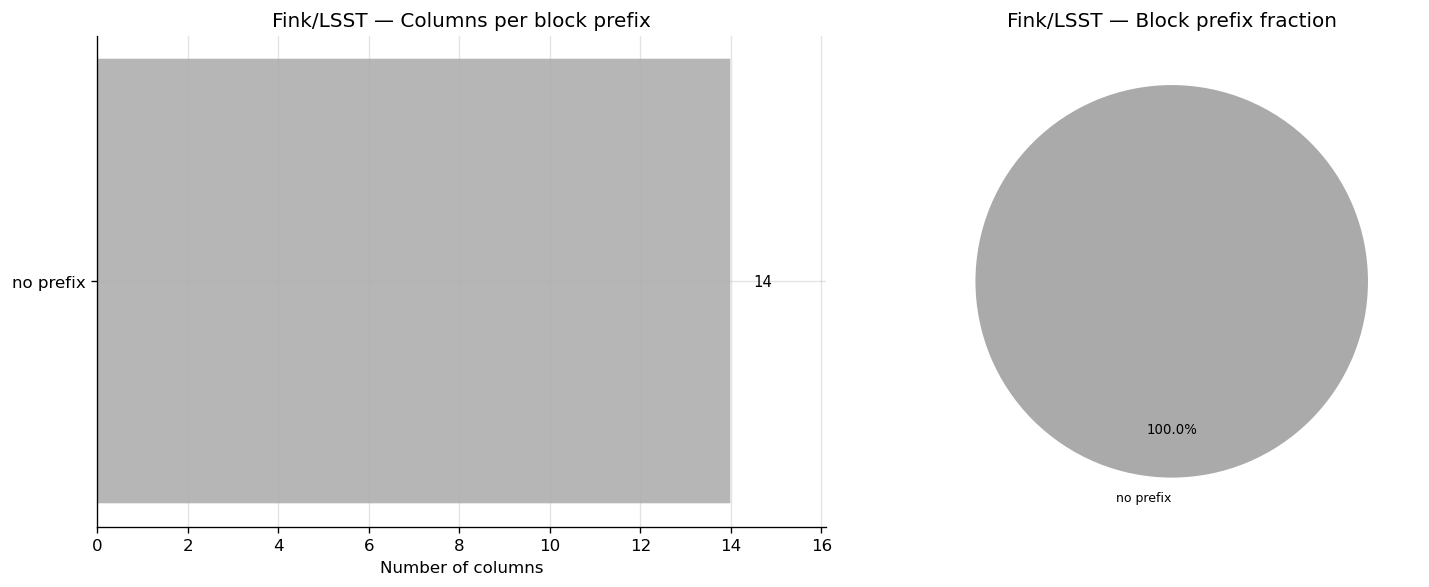

In [8]:
if 'prefix' in df.columns:
    prefix_counts = df['prefix'].value_counts()

    PREFIX_LABELS = {
        'i' : 'i: input\n(raw Rubin alert)',
        'r' : 'r: Rubin-derived\n(Fink processed)',
        'd' : 'd: science modules\n(classifiers / xmatch)',
        'f' : 'f: Fink metadata\n(broker stats)',
        'b' : 'b: binary / cutouts',
        'unknown': 'no prefix',
    }
    PREFIX_COLORS = {
        'i': '#4c9be8',
        'r': '#f28b30',
        'd': '#5cb85c',
        'f': '#d9534f',
        'b': '#9b59b6',
        'unknown': '#aaaaaa',
    }

    labels = [PREFIX_LABELS.get(p, p) for p in prefix_counts.index]
    colors = [PREFIX_COLORS.get(p, '#888888') for p in prefix_counts.index]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Bar chart
    ax = axes[0]
    bars = ax.barh(labels[::-1], prefix_counts.values[::-1],
                   color=colors[::-1], alpha=0.85, edgecolor='white')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{int(w):,}', va='center', ha='left', fontsize=9)
    ax.set_xlabel('Number of columns')
    ax.set_title('Fink/LSST — Columns per block prefix')
    ax.set_xlim(0, prefix_counts.max() * 1.15)

    # Pie chart
    ax2 = axes[1]
    wedges, texts, autotexts = ax2.pie(
        prefix_counts.values,
        labels=labels,
        colors=colors,
        autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
        startangle=90,
        pctdistance=0.75,
        textprops={'fontsize': 7.5},
    )
    for at in autotexts:
        at.set_fontsize(8)
    ax2.set_title('Fink/LSST — Block prefix fraction')

    plt.tight_layout()
    savefig('fink_blocks_prefix_distribution')
    plt.show()

## 6. Data-type distribution

In [9]:
# Look for a 'type' or 'dtype' column in the block definition
type_col = next((c for c in df.columns if c.lower() in ('type', 'dtype', 'datatype', 'data_type')), None)
print(f'Type column found: {type_col}')

if type_col:
    type_counts = df[type_col].fillna('unknown').value_counts()
    print(f'\nUnique data types ({len(type_counts)}):')
    print(type_counts.to_string())

Type column found: None


In [10]:
if type_col and len(type_counts) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, len(type_counts) * 0.45)))
    cmap   = plt.get_cmap('tab20')
    colors = [cmap(i / len(type_counts)) for i in range(len(type_counts))]

    bars = ax.barh(type_counts.index[::-1], type_counts.values[::-1],
                   color=colors[::-1], alpha=0.85, edgecolor='white')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.2, bar.get_y() + bar.get_height() / 2,
                f'{int(w):,}', va='center', ha='left', fontsize=8)

    ax.set_xlabel('Number of columns')
    ax.set_title('Fink/LSST — Column data-type distribution')
    ax.set_xlim(0, type_counts.max() * 1.18)
    plt.tight_layout()
    savefig('fink_blocks_datatype_distribution')
    plt.show()

## 7. Data-type breakdown per block prefix

In [11]:
if type_col and 'prefix' in df.columns:
    pivot = (
        df.groupby(['prefix', type_col])
          .size()
          .unstack(fill_value=0)
          .sort_index()
    )
    print('Columns per (prefix, type):')
    print(pivot.to_string())

    fig, ax = plt.subplots(figsize=(12, 5))
    cmap   = plt.get_cmap('tab20')
    bottom = np.zeros(len(pivot))
    for i, col in enumerate(pivot.columns):
        vals = pivot[col].values
        ax.bar(pivot.index, vals, bottom=bottom,
               label=col, color=cmap(i / len(pivot.columns)), alpha=0.85)
        bottom += vals

    ax.set_title('Fink/LSST — Data-type breakdown per block prefix')
    ax.set_xlabel('Block prefix')
    ax.set_ylabel('Number of columns')
    ax.legend(title='Data type', fontsize=8, loc='upper right',
              ncol=2, framealpha=0.9)
    plt.tight_layout()
    savefig('fink_blocks_datatype_per_prefix')
    plt.show()

## 8. Column name length distribution

  -> saved fink_blocks_name_lengths.{pdf,png}


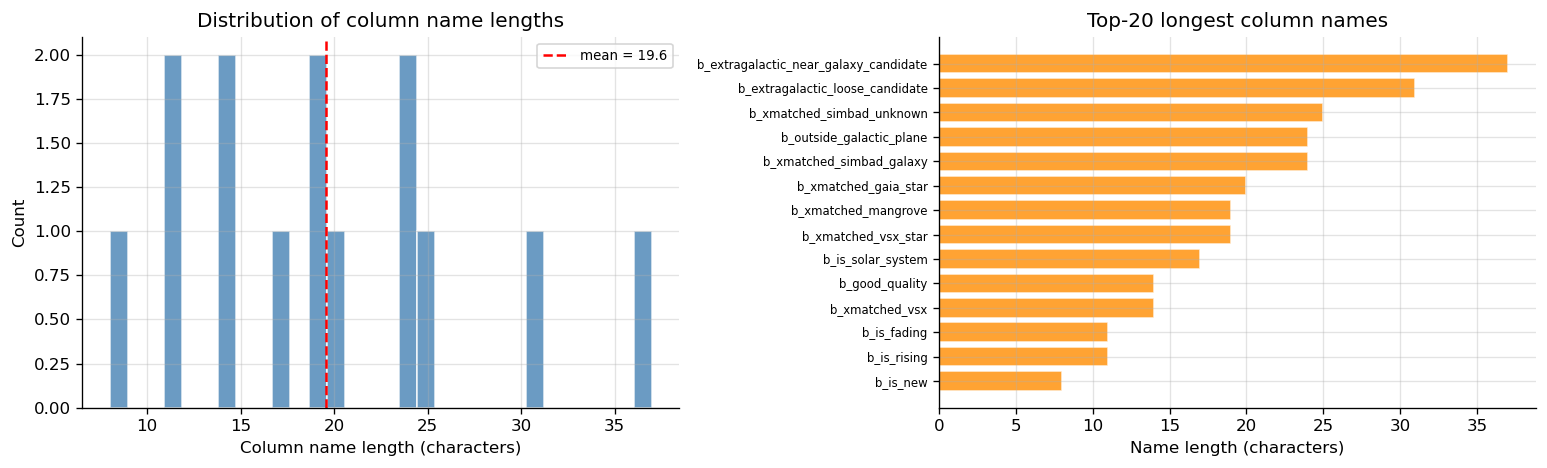

In [12]:
if 'column' in df.columns:
    # Strip prefix (e.g. 'i:midpointMjdTai' -> 'midpointMjdTai')
    bare_names   = df['column'].str.replace(r'^[a-z]:', '', regex=True)
    name_lengths = bare_names.str.len()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histogram of column name lengths
    ax = axes[0]
    ax.hist(name_lengths, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Column name length (characters)')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of column name lengths')
    ax.axvline(name_lengths.mean(), color='red', ls='--', lw=1.5,
               label=f'mean = {name_lengths.mean():.1f}')
    ax.legend(fontsize=8)

    # Top-20 longest column names
    ax2 = axes[1]
    top20 = bare_names.sort_values(key=lambda s: s.str.len(), ascending=False).head(20)
    ax2.barh(range(len(top20)), top20.str.len().values[::-1],
             color='darkorange', alpha=0.8, edgecolor='white')
    ax2.set_yticks(range(len(top20)))
    ax2.set_yticklabels(top20.values[::-1], fontsize=7)
    ax2.set_xlabel('Name length (characters)')
    ax2.set_title('Top-20 longest column names')

    plt.tight_layout()
    savefig('fink_blocks_name_lengths')
    plt.show()

## 9. Per-prefix column listing

In [13]:
if 'prefix' in df.columns:
    desc_col = next((c for c in df.columns if 'desc' in c.lower()), None)

    for prefix in sorted(df['prefix'].unique()):
        sub = df[df['prefix'] == prefix].reset_index(drop=True)
        label = {
            'i': 'i: — raw Rubin LSST alert fields (diaSource / diaObject)',
            'r': 'r: — Rubin-derived fields (Fink-processed)',
            'd': 'd: — Fink science module outputs (classifiers, cross-matches)',
            'f': 'f: — Fink broker metadata',
            'b': 'b: — binary / cutout metadata',
        }.get(prefix, f'{prefix}: — unknown block')

        print(f'\n{"="*70}')
        print(f'  {label}  ({len(sub)} columns)')
        print('='*70)

        cols_to_show = ['column']
        if type_col:
            cols_to_show.append(type_col)
        if desc_col:
            cols_to_show.append(desc_col)

        display(sub[cols_to_show])

        # Save per-prefix CSV
        out = os.path.join(DIR_DATA, f'blocks_prefix_{prefix}.csv')
        sub[cols_to_show].to_csv(out, index=False)
        print(f'  -> saved {out}')


  unknown: — unknown block  (14 columns)


,column,description
0,b_extragalactic_loose_candidate,Flag for alerts in Rubin that are extragalactic candidates
1,b_extragalactic_near_galaxy_candidate,Flag for alerts in Rubin that are extragalactic candidates near a known galaxy
2,b_good_quality,Select alerts with good quality for science
3,b_is_fading,Return alerts with fading lightcurve in one filter.
4,b_is_new,Return alerts for which the underlying object is seen for the first time by ...
5,b_is_rising,Return alerts with rising lightcurve in one filter.
6,b_is_solar_system,Return alerts that are asteroids according to Rubin
7,b_outside_galactic_plane,Return alerts outside the galactic plane (+/- |20| deg)
8,b_xmatched_gaia_star,Return alerts xmatched to stars with good parallax with Gaia.
9,b_xmatched_mangrove,Return alerts xmatched with a Mangrove galaxy.


  -> saved data_FINKAPIBLOCKS05/blocks_prefix_unknown.csv


## 10. Cross-reference with other endpoints

Check which columns defined in the blocks actually appear in the live
`/api/v1/statistics` and `/api/v1/tags` responses.

In [14]:
# /api/v1/statistics
r_stats = requests.get(
    f'{FINK_API}/api/v1/statistics',
    params={'date': '', 'output-format': 'csv'},
    timeout=30
)
if r_stats.status_code == 200:
    df_stats  = pd.read_csv(StringIO(r_stats.text))
    stats_cols = set(df_stats.columns.tolist())
    print(f'Columns from /api/v1/statistics : {len(stats_cols)}')
else:
    stats_cols = set()
    print(f'Could not fetch /api/v1/statistics: HTTP {r_stats.status_code}')

# /api/v1/tags
r_tags = requests.get(
    f'{FINK_API}/api/v1/tags',
    params={'tag': 'extragalactic_new_candidate', 'n': 10, 'output-format': 'json'},
    timeout=30
)
if r_tags.status_code == 200 and r_tags.json():
    df_tags   = pd.DataFrame(r_tags.json())
    tags_cols = set(df_tags.columns.tolist())
    print(f'Columns from /api/v1/tags       : {len(tags_cols)}')
else:
    tags_cols = set()
    print(f'Could not fetch /api/v1/tags: HTTP {r_tags.status_code}')

Columns from /api/v1/statistics : 22
Columns from /api/v1/tags       : 131


In [15]:
if 'column' in df.columns and (stats_cols or tags_cols):
    block_cols    = set(df['column'].tolist())
    all_live_cols = stats_cols | tags_cols
    in_blocks     = all_live_cols & block_cols
    not_in_blocks = all_live_cols - block_cols

    print(f'Live columns found in block definitions : {len(in_blocks):3d}')
    print(f'Live columns NOT in block definitions   : {len(not_in_blocks):3d}')
    if not_in_blocks:
        print('  (likely endpoint-specific computed columns):')
        for c in sorted(not_in_blocks):
            print(f'    {c}')

Live columns found in block definitions :   0
Live columns NOT in block definitions   : 150
  (likely endpoint-specific computed columns):
    f:alerts
    f:alerts_g
    f:alerts_i
    f:alerts_r
    f:alerts_u
    f:alerts_y
    f:alerts_z
    f:clf_cats_class
    f:clf_cats_score
    f:clf_earlySNIa_score
    f:clf_elephant_kstest_science
    f:clf_elephant_kstest_template
    f:clf_snnSnVsOthers_score
    f:fink_broker_version
    f:fink_science_version
    f:glint_trail
    f:in_tns
    f:isDipole
    f:is_cataloged
    f:is_first
    f:is_sso
    f:lsst_schema_version
    f:night
    f:objects
    f:pixelFlags_cr
    f:pixelFlags_saturated
    f:pixelFlags_streak
    f:visits
    f:xm_gaiadr3_DR3Name
    f:xm_gaiadr3_Plx
    f:xm_gaiadr3_VarFlag
    f:xm_gaiadr3_e_Plx
    f:xm_gcvs_type
    f:xm_legacydr8_e_zphot
    f:xm_legacydr8_fqual
    f:xm_legacydr8_pstar
    f:xm_legacydr8_zphot
    f:xm_mangrove_2MASS_name
    f:xm_mangrove_HyperLEDA_name
    f:xm_mangrove_ang_dist
    f

## 11. Block completeness histogram

For each block prefix, how many columns defined in the blocks actually appear
in the live `/api/v1/tags` response?

 prefix  defined  in_tags_api  pct
unknown       14            0  0.0
  -> saved fink_blocks_completeness.{pdf,png}


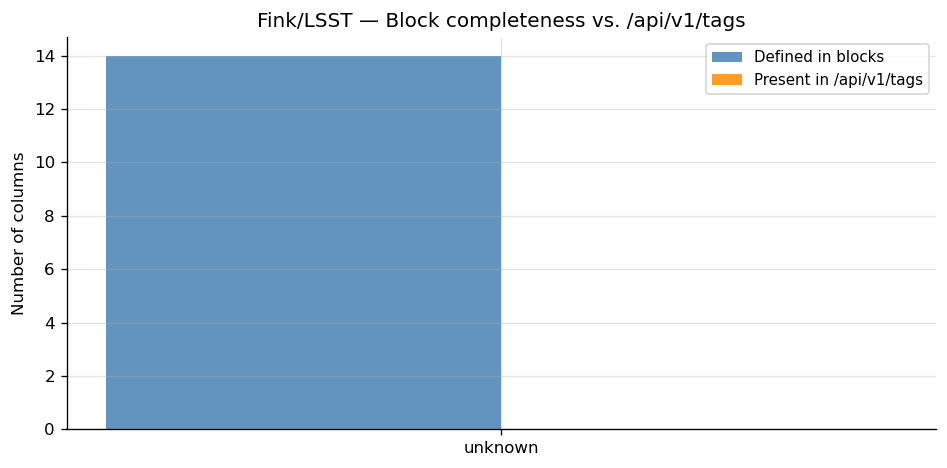

In [16]:
if 'prefix' in df.columns and tags_cols:
    completeness = []
    for prefix, sub in df.groupby('prefix'):
        defined = set(sub['column'].tolist())
        present = defined & tags_cols
        completeness.append({
            'prefix'     : prefix,
            'defined'    : len(defined),
            'in_tags_api': len(present),
            'pct'        : len(present) / len(defined) * 100 if defined else 0,
        })

    df_comp = pd.DataFrame(completeness).sort_values('prefix')
    print(df_comp.to_string(index=False))

    # Save
    df_comp.to_csv(os.path.join(DIR_DATA, 'blocks_completeness.csv'), index=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(df_comp))
    w = 0.35
    ax.bar(x - w/2, df_comp['defined'],     width=w, label='Defined in blocks',
           color='steelblue',  alpha=0.85)
    ax.bar(x + w/2, df_comp['in_tags_api'], width=w, label='Present in /api/v1/tags',
           color='darkorange', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(df_comp['prefix'], fontsize=10)
    ax.set_ylabel('Number of columns')
    ax.set_title('Fink/LSST — Block completeness vs. /api/v1/tags')
    ax.legend(fontsize=9)
    plt.tight_layout()
    savefig('fink_blocks_completeness')
    plt.show()

## 12. Keyword analysis of column names

Extract recurring words from CamelCase / snake_case column names to identify thematic groups.

  -> saved fink_blocks_keywords_top50.{pdf,png}


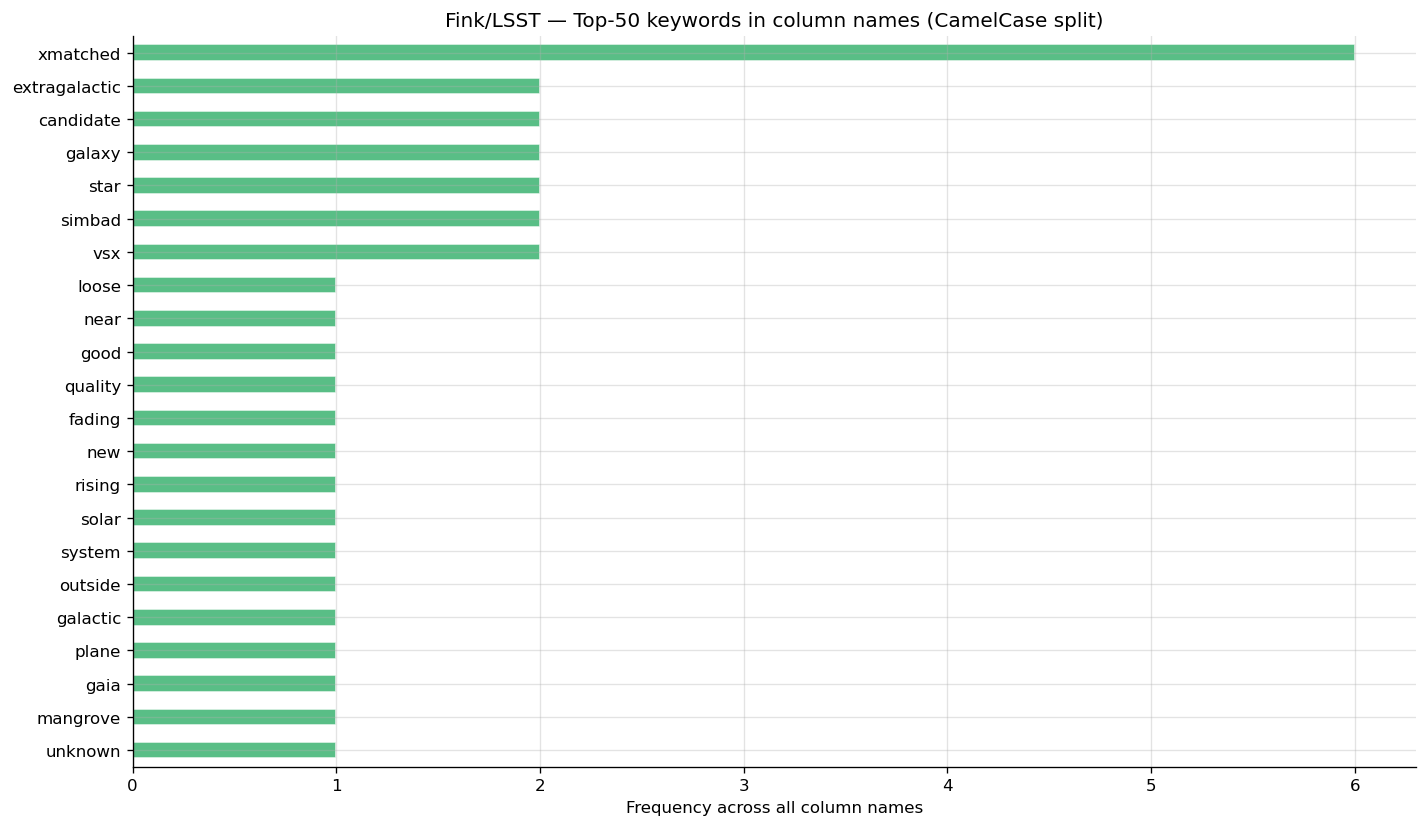


Top 20 keywords:
  xmatched                 6
  extragalactic            2
  candidate                2
  galaxy                   2
  star                     2
  simbad                   2
  vsx                      2
  loose                    1
  near                     1
  good                     1
  quality                  1
  fading                   1
  new                      1
  rising                   1
  solar                    1
  system                   1
  outside                  1
  galactic                 1
  plane                    1
  gaia                     1


In [17]:
def split_name(name: str) -> list:
    """Split a CamelCase or snake_case name into lowercase tokens."""
    name   = re.sub(r'^[a-z]:', '', name)          # strip 'x:' prefix
    name   = re.sub(r'([A-Z])', r' \1', name)      # CamelCase -> tokens
    tokens = re.split(r'[_\s]+', name.lower())     # split on _ and spaces
    return [t for t in tokens if len(t) > 2]       # discard very short tokens

if 'column' in df.columns:
    all_tokens = []
    for col in df['column']:
        all_tokens.extend(split_name(str(col)))

    token_counts = Counter(all_tokens)
    top50 = pd.Series(dict(token_counts.most_common(50)))

    fig, ax = plt.subplots(figsize=(12, 7))
    top50[::-1].plot.barh(ax=ax, color='mediumseagreen', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Frequency across all column names')
    ax.set_title('Fink/LSST — Top-50 keywords in column names (CamelCase split)')
    plt.tight_layout()
    savefig('fink_blocks_keywords_top50')
    plt.show()

    print('\nTop 20 keywords:')
    for word, count in token_counts.most_common(20):
        print(f'  {word:<20s}  {count:4d}')

    # Save keyword counts
    kw_df = pd.DataFrame(token_counts.most_common(), columns=['keyword', 'count'])
    kw_df.to_csv(os.path.join(DIR_DATA, 'blocks_keywords.csv'), index=False)

## 13. Summary table

In [18]:
summary_rows = [('Total column definitions', f'{len(df):,}')]

if 'prefix' in df.columns:
    for prefix, count in df['prefix'].value_counts().items():
        label = {
            'i': 'i: input (raw Rubin)',
            'r': 'r: Rubin-derived',
            'd': 'd: science modules',
            'f': 'f: Fink metadata',
            'b': 'b: binary/cutouts',
        }.get(prefix, prefix)
        summary_rows.append((f'  {label}', f'{count:,}'))

if type_col:
    summary_rows.append(('Distinct data types', str(df[type_col].nunique())))
if tags_cols:
    summary_rows.append(('Columns active in /api/v1/tags', str(len(tags_cols))))
if stats_cols:
    summary_rows.append(('Columns active in /api/v1/statistics', str(len(stats_cols))))

summary_rows += [
    ('Data saved to', DIR_DATA),
    ('Figures saved to', DIR_FIGS),
]

df_summary = pd.DataFrame(summary_rows, columns=['Metric', 'Value'])
df_summary.to_csv(os.path.join(DIR_DATA, 'blocks_summary.csv'), index=False)
df_summary

,Metric,Value
0,Total column definitions,14
1,unknown,14
2,Columns active in /api/v1/tags,131
3,Columns active in /api/v1/statistics,22
4,Data saved to,data_FINKAPIBLOCKS05
5,Figures saved to,figs_FINKAPIBLOCKS05
